<a href="https://colab.research.google.com/github/DaviNegreiros/EyeAiRH/blob/main/C%C3%B3pia_de_Trabalho_2_TEMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<left><img src="https://i.ibb.co/zWjkHsWJ/marca-final-rgb-campanha-2025-versao02.png" width="35%" height="35%"></left>

# **VERSÃO DAVI**
# Trabalho 2 — Classificação de Imagens Fundo de Olho
### Disciplina: Tópicos Especiais (Visão Computacional) - Prof. Vinicius Rispoli | PyTorch

---

Autores: Davi Monteiro de Negreiros e Diogo Oliveira Ferreira

Matrícula: 232013971 e 231011266, respectivamente

Data de entrega: 31 de maio de 2026

Local de entrega: https://forms.gle/FxDdfWNwnqdAJGnL6

---

# Classificação de imagens de fundo de olho
## Objetivo:
- Construir um classificador capaz de determinar se uma imagem de fundo de olho é normal ou
possui retinopatia hipertensiva
## Por que?
- A retinopatia hipertensiva é uma alteração da retina causada pelos efeitos da hipertensão arterial
sobre os vasos sanguíneos retinianos. Como a retina permite a visualização direta de pequenos vasos, o
fundo de olho pode revelar sinais de dano vascular, como estreitamento arteriolar, alterações nos cruzamentos
arteriovenosos, tortuosidade vascular, hemorragias, exsudatos, manchas algodonosas e, em casos graves, edema
de papila.
- A doença está relacionada ao controle inadequado da pressão arterial e pode indicar risco aumentado
de complicações sistêmicas, como acidente vascular cerebral, doença cardiovascular e comprometimento renal.
## Qual a dificuldade?
- Primeiramente, imagens com retinopatia hipertensiva são escassas. Vocês irão observar
que no dataset do trabalho a razão entre imagens normais e alteradas é muito desigual. Em segundo lugar,
em visão computacional, sua identificação é desafiadora porque os sinais podem ser sutis e confundidos com
outras alterações vasculares ou problemas de qualidade da imagem.
## Do que se trata o dataset?
- O conjunto de dados do trabalho é a combinação de dois datasets diferentes:
o BRSET e o ODIR5k. O BRSET é um conjunto de dados brasileiro de imagens de fundo de olho criado
especificamente para pesquisas em inteligência artificial e visão computacional aplicada à oftalmologia. Ele
reúne fotografias coloridas da retina de pacientes brasileiros, acompanhadas de rótulos clínicos e metadados
como idade, sexo, comorbidades e informações relacionadas à qualidade da imagem. O dataset é multilabel,
ou seja, uma mesma imagem pode apresentar mais de uma alteração, como retinopatia diabética, drusas,
aumento da escavação do disco óptico, fundo miópico, degeneração macular relacionada à idade e retinopatia
hipertensiva.
- Já o ODIR5K é um conjunto de dados oftalmológico composto por imagens de fundo de olho
dos olhos esquerdo e direito de pacientes, acompanhado de informações como idade, sexo e palavras-chave
diagnósticas. Ele foi desenvolvido também para tarefas de reconhecimento automático de doenças oculares
e inclui categorias como normal, diabetes, glaucoma, catarata, degeneração macular relacionada à idade,
hipertensão, miopia patológica e outras alterações. O ODIR5K também pode conter múltiplas condições
associadas ao mesmo paciente ou aos dois olhos, o que o torna útil para problemas de classificação multilabel
e para estudos comparativos entre doenças oftalmológicas.
## Como os dados foram separados?
- Do BRSET foram separadas todas as 8457 imagens normais e as
284 imagens que possuem retinopatia hipertensiva. Do ODIR5k foram separadas todas as 193 imagens
com retinopatia hipertensiva apenas.
## O trabalho deve executado em seis etapas:
1. Realizar a análise exploratória dos dados, avaliação da qualidade das imagens e o pré-processamento do dataset,
caso julgue necessário. Os metadados de cada dataset estão nos arquivos labels_brset_filt.xlsx e data_filt.xlsx.
2. Implementar estratégias para mitigar o desbalanceamento massivo, aplicando técnicas de aumento de dados,
controle da amostragem durante o treinamento (oversampling) e escolha de funções de perda adequada como,
por exemplo, focal loss [1] e asymmetric loss [2].
3. Controlar que não haja vazamento de pacientes. O seu classificador ficará enviesado se você treinar e testar
com imagens do mesmo paciente, não queremos isso!
4. Aplicar as técnicas de transferência de aprendizado e ajuste fino utilizando algum tipo de arquitetura pré-
treinada (ex: VGG16, ResNet, MobileNetV2, ConvNext, ViT, Swin, ...) como extratora de características.
5. Importante! Façam dois treinamentos diferentes: um só com os dados do BRSET e o segundo combinando
as imagens do BRSET e ODIR5k. Será que o número ligeiramente maior de amostras melhora o classificador?
6. Analisar e comparar criticamente o desempenho de diferentes abordagens usando métricas de qualidade (AUC-
ROC, AUC-PR, Acurácia, Precisão, Recall, F1-Score, Matriz de Confusão).

## Como o trabalho deve ser entregue
- Em um notebook jupyter completamente comentado e identificado
com os passos da solução do problema e o porquê a estratégia/arquitetura/otimização dos parâmetros foram
escolhidos. Citar as referências necessárias sempre que for o caso. Faça o trabalho como se fosse um artigo
científico, com introdução, métodos, resultados e conclusão. Trabalhos que tiverem apenas código irão
perder ponto!

## Sumário

1. Introdução: contexto clínico, motivação e desafios
2. Setup: bibliotecas, semente de reprodutibilidade, paths
3. Carregamento de metadados e construção do DataFrame mestre
4. Análise Exploratória (EDA): distribuição de classes, qualidade das imagens, amostras visuais
5. Split paciente-aware: separação treino/val/teste sem vazamento de paciente
6. Pré-processamento e Data Augmentation
7. Funções de perda: Focal Loss e Asymmetric Loss
8. Modelo: ResNet50 com transfer learning
9. Loop de treino em duas fases: warm-up da head e fine-tune completo
10. Experimento 1: treino apenas com BRSET
11. Experimento 2: treino com BRSET e ODIR5k
12. Resultados e comparação crítica
13. Discussão
14. Conclusão
15. Referências

---

## 1. Introdução

A retinopatia hipertensiva é uma alteração da retina causada pelo efeito prolongado da hipertensão arterial sobre a microvasculatura retiniana. Como o fundo de olho permite observar diretamente pequenos vasos sanguíneos, ele funciona como uma janela não invasiva para avaliar o estado vascular do paciente como um todo. Os sinais típicos da doença incluem estreitamento arteriolar, alterações nos cruzamentos arteriovenosos, tortuosidade vascular, hemorragias, exsudatos e, em quadros mais graves, edema de papila. Identificar esses sinais de forma automatizada é clinicamente útil porque viabiliza triagem em larga escala e ajuda a sinalizar pacientes com risco aumentado de AVC, doença cardiovascular e comprometimento renal.

Do ponto de vista de aprendizado de máquina, o problema apresenta três dificuldades principais. A primeira é o desbalanceamento muito severo: no recorte do BRSET fornecido, a razão entre imagens normais e imagens com retinopatia hipertensiva é de aproximadamente 30 para 1 (8457 normais contra 284 alteradas). Um classificador treinado de forma ingênua tende a aprender a sempre prever "normal", já que isso minimiza a perda média sem que o modelo precise de fato distinguir as classes. A segunda dificuldade é que os sinais da doença são sutis e podem se confundir tanto com outras retinopatias (em especial a retinopatia diabética) quanto com artefatos de qualidade da imagem, como falta de foco e iluminação irregular. A terceira é a heterogeneidade das fontes: o BRSET é brasileiro e o ODIR5k é chinês, com câmeras, protocolos de aquisição e populações distintas. Combinar os dois conjuntos exige cuidado para que o modelo aprenda sinal clínico e não acabe aprendendo a assinatura do domínio.

Para lidar com esses pontos, este trabalho aplica um conjunto coordenado de estratégias. O split de treino, validação e teste é feito por paciente, com `GroupShuffleSplit`, garantindo que imagens do mesmo paciente nunca apareçam em conjuntos diferentes. O data augmentation usa transformações geométricas e fotométricas controladas, evitando distorções elásticas que poderiam alterar a aparência dos vasos. O oversampling da classe minoritária é feito durante o treino via `WeightedRandomSampler`, o que aumenta a proporção efetiva de exemplos positivos por batch sem precisar duplicar arquivos em disco. Como funções de perda específicas para desbalanceamento, usamos Focal Loss [1] e Asymmetric Loss [2], comparando o efeito de cada uma. A arquitetura base é uma ResNet50 pré-treinada no ImageNet, ajustada em duas fases: primeiro a cabeça classificadora, depois o modelo inteiro com uma taxa de aprendizado menor. Por fim, fazemos dois experimentos completos, um treinando só com BRSET e outro com BRSET combinado com ODIR5k, mantendo o mesmo conjunto de teste em ambos para que a comparação seja justa.


## 1. Preparação do Ambiente     
Esse código realiza toda a preparação inicial do ambiente para o treinamento de um modelo de visão computacional voltado à detecção de retinopatia hipertensiva em imagens de fundo de olho. Inicialmente, são instaladas e importadas bibliotecas essenciais para manipulação de dados, processamento de imagens, visualização gráfica, métricas de avaliação e treinamento de redes neurais profundas utilizando PyTorch, Albumentations e timm. Em seguida, são configuradas seeds de reprodutibilidade para garantir consistência experimental, além da definição automática do dispositivo de execução (CPU ou GPU), incluindo exibição das informações da placa gráfica disponível. O código também monta o Google Drive no ambiente do Google Colab, define todos os caminhos do dataset e diretórios de saída do projeto, verifica automaticamente a existência dos arquivos e pastas necessários, e cria uma estrutura centralizada de hiperparâmetros contendo configurações do treinamento, como resolução das imagens, batch size, número de épocas, learning rates, regularização, early stopping e modelo base utilizado, neste caso a EfficientNet-B3.

In [ ]:
# ============================================================
# 1. PREPARAÇÃO DO AMBIENTE
# ============================================================

# ============================================================
# Instalação das bibliotecas
# ============================================================

!pip install -q timm==1.0.11 albumentations==1.4.18 openpyxl==3.1.5


# ============================================================
# Imports principais
# ============================================================

import os
import gc
import time
import json
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

import cv2
from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader,
    WeightedRandomSampler
)

from torch.cuda.amp import autocast, GradScaler

import timm

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import GroupShuffleSplit

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)


# ============================================================
# Configurações visuais e warnings
# ============================================================

warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

plt.rcParams['figure.figsize'] = (8, 5)


# ============================================================
# Reprodutibilidade
# ============================================================

SEED = 42

def set_seed(seed=SEED):

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    torch.cuda.manual_seed(seed)

    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True

    torch.backends.cudnn.benchmark = False


set_seed()


# ============================================================
# Configuração de device
# ============================================================

DEVICE = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print('=' * 50)
print(f'Device: {DEVICE}')

if torch.cuda.is_available():

    print(f'GPU: {torch.cuda.get_device_name(0)}')

    total_mem = (
        torch.cuda.get_device_properties(0).total_memory / 1e9
    )

    print(f'VRAM: {total_mem:.1f} GB')

print('=' * 50)


# ============================================================
# Montagem do Google Drive
# ============================================================

from google.colab import drive

drive.mount('/content/drive')


# ============================================================
# Paths do projeto
# ============================================================

# Pasta principal do dataset
DATA_ROOT = Path(
    '/content/drive/MyDrive/VC/dataset'
)

# Pasta de saída
OUT_DIR = Path(
    '/content/drive/MyDrive/VC/hr_outputs'
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Diretórios das imagens
DIR_NORMAL = DATA_ROOT / 'normal'

DIR_HR_BRSET = DATA_ROOT / 'hr_brset'

DIR_HR_ODIR = DATA_ROOT / 'hr_odir5k'

# Planilhas
XLSX_BRSET = DATA_ROOT / 'labels_brset_filt.xlsx'

XLSX_ODIR = DATA_ROOT / 'data_filt.xlsx'


# ============================================================
# Verificação dos paths
# ============================================================

print('\nVerificando diretórios...\n')

paths = {
    'DATA_ROOT'   : DATA_ROOT,
    'DIR_NORMAL'  : DIR_NORMAL,
    'DIR_HR_BRSET': DIR_HR_BRSET,
    'DIR_HR_ODIR' : DIR_HR_ODIR,
    'XLSX_BRSET'  : XLSX_BRSET,
    'XLSX_ODIR'   : XLSX_ODIR,
    'OUT_DIR'     : OUT_DIR
}

for name, path in paths.items():

    exists = path.exists()

    status = 'OK' if exists else 'ERRO'

    print(f'[{status}] {name}: {path}')


# ============================================================
# Configurações do experimento
# ============================================================

CFG = {

    # Imagem
    'img_size': 300,

    # Loader
    'batch_size': 16,
    'num_workers': 2,

    # Epochs
    'epochs_head': 5,
    'epochs_full': 15,

    # Learning rates
    'lr_head': 1e-3,
    'lr_full': 1e-4,

    # Regularização
    'weight_decay': 1e-4,

    # Early stopping
    'early_stop_patience': 5,

    # Split
    'val_size': 0.15,
    'test_size': 0.15,

    # Seed
    'seed': SEED,

    # Modelo
    'model_name': 'efficientnet_b3',

    # Mixed precision
    'use_amp': True
}


# ============================================================
# Mostrar configurações
# ============================================================

print('\nConfigurações do experimento:\n')

print(
    json.dumps(
        CFG,
        indent=4
    )
)

Device: cpu
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Verificando diretórios...

[OK] DATA_ROOT: /content/drive/MyDrive/VC/dataset
[OK] DIR_NORMAL: /content/drive/MyDrive/VC/dataset/normal
[OK] DIR_HR_BRSET: /content/drive/MyDrive/VC/dataset/hr_brset
[OK] DIR_HR_ODIR: /content/drive/MyDrive/VC/dataset/hr_odir5k
[OK] XLSX_BRSET: /content/drive/MyDrive/VC/dataset/labels_brset_filt.xlsx
[OK] XLSX_ODIR: /content/drive/MyDrive/VC/dataset/data_filt.xlsx
[OK] OUT_DIR: /content/drive/MyDrive/VC/hr_outputs

Configurações do experimento:

{
    "img_size": 300,
    "batch_size": 16,
    "num_workers": 2,
    "epochs_head": 5,
    "epochs_full": 15,
    "lr_head": 0.001,
    "lr_full": 0.0001,
    "weight_decay": 0.0001,
    "early_stop_patience": 5,
    "val_size": 0.15,
    "test_size": 0.15,
    "seed": 42,
    "model_name": "efficientnet_b3",
    "use_amp": true
}


estrutura do dataset

In [ ]:
# ============================================================
# INSPEÇÃO DA ESTRUTURA DO DATASET
# ============================================================

import os
import pandas as pd
from PIL import Image


# ============================================================
# 1. Estrutura das pastas
# ============================================================

print('=' * 70)
print('ESTRUTURA DAS PASTAS')
print('=' * 70)

for root, dirs, files in os.walk(DATA_ROOT):

    print(f'\n📁 {root}')

    if len(files) > 0:

        print(f'Arquivos encontrados: {len(files)}')

        print('Exemplos:')

        for f in files[:5]:
            print(f'   - {f}')

    else:
        print('Sem arquivos')

    print('-' * 70)


# ============================================================
# 2. Verificar quantidade de imagens por pasta
# ============================================================

print('\n')
print('=' * 70)
print('QUANTIDADE DE IMAGENS')
print('=' * 70)

image_exts = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')

folders = {
    'NORMAL': DIR_NORMAL,
    'HR_BRSET': DIR_HR_BRSET,
    'HR_ODIR': DIR_HR_ODIR
}

for name, folder in folders.items():

    if folder.exists():

        imgs = [
            f for f in folder.iterdir()
            if f.suffix.lower() in image_exts
        ]

        print(f'{name}: {len(imgs)} imagens')

    else:

        print(f'{name}: pasta não encontrada')


# ============================================================
# 3. Mostrar exemplos de nomes de arquivos
# ============================================================

print('\n')
print('=' * 70)
print('EXEMPLOS DE NOMES DE ARQUIVOS')
print('=' * 70)

for name, folder in folders.items():

    if folder.exists():

        imgs = [
            f.name for f in folder.iterdir()
            if f.suffix.lower() in image_exts
        ]

        print(f'\n{name}')

        for img in imgs[:10]:
            print(f'  - {img}')


# ============================================================
# 4. Informações das imagens
# ============================================================

print('\n')
print('=' * 70)
print('INFORMAÇÕES DAS IMAGENS')
print('=' * 70)

for name, folder in folders.items():

    if folder.exists():

        imgs = [
            f for f in folder.iterdir()
            if f.suffix.lower() in image_exts
        ]

        if len(imgs) > 0:

            img_path = imgs[0]

            try:

                img = Image.open(img_path)

                print(f'\n{name}')

                print(f'Arquivo exemplo: {img_path.name}')

                print(f'Resolução: {img.size}')

                print(f'Modo de cor: {img.mode}')

                print(f'Formato: {img.format}')

            except Exception as e:

                print(f'Erro ao abrir imagem: {e}')


# ============================================================
# 5. Ler planilha BRSET
# ============================================================

print('\n')
print('=' * 70)
print('PLANILHA BRSET')
print('=' * 70)

if XLSX_BRSET.exists():

    df_brset = pd.read_excel(XLSX_BRSET)

    print('\nShape:')
    print(df_brset.shape)

    print('\nColunas:')
    print(df_brset.columns.tolist())

    print('\nPrimeiras linhas:')
    display(df_brset.head())

else:

    print('Arquivo não encontrado')


# ============================================================
# 6. Ler planilha ODIR
# ============================================================

print('\n')
print('=' * 70)
print('PLANILHA ODIR')
print('=' * 70)

if XLSX_ODIR.exists():

    df_odir = pd.read_excel(XLSX_ODIR)

    print('\nShape:')
    print(df_odir.shape)

    print('\nColunas:')
    print(df_odir.columns.tolist())

    print('\nPrimeiras linhas:')
    display(df_odir.head())

else:

    print('Arquivo não encontrado')


# ============================================================
# 7. Estatísticas gerais
# ============================================================

print('\n')
print('=' * 70)
print('RESUMO GERAL')
print('=' * 70)

total_images = 0

for name, folder in folders.items():

    if folder.exists():

        imgs = [
            f for f in folder.iterdir()
            if f.suffix.lower() in image_exts
        ]

        total_images += len(imgs)

print(f'Total de imagens: {total_images}')

print('\nDataset pronto para inspeção.')

ESTRUTURA DAS PASTAS

📁 /content/drive/MyDrive/VC/dataset
Arquivos encontrados: 3
Exemplos:
   - data_filt.xlsx
   - labels_brset_filt.xlsx
   - .DS_Store
----------------------------------------------------------------------

📁 /content/drive/MyDrive/VC/dataset/hr_brset
Arquivos encontrados: 284
Exemplos:
   - img03675.jpg
   - img03676.jpg
   - img01629.jpg
   - img02485.jpg
   - img02526.jpg
----------------------------------------------------------------------

📁 /content/drive/MyDrive/VC/dataset/hr_odir5k
Arquivos encontrados: 194
Exemplos:
   - 4142_left.jpg
   - 4199_left.jpg
   - 413_left.jpg
   - 675_left.jpg
   - 1056_left.jpg
----------------------------------------------------------------------

📁 /content/drive/MyDrive/VC/dataset/normal
Arquivos encontrados: 6185
Exemplos:
   - img13938.jpg
   - img13944.jpg
   - img13874.jpg
   - img13849.jpg
   - img13700.jpg
----------------------------------------------------------------------


QUANTIDADE DE IMAGENS
NORMAL: 6185 image

,subset,image_id,patient_id,label_hr,label_pure_normal,quality,focus,Illuminaton,image_field,artifacts,...,nevus,amd,vascular_occlusion,hypertensive_retinopathy,drusens,hemorrhage,retinal_detachment,myopic_fundus,increased_cup_disc,other
0,hr,img00339,171,1,0,Adequate,1,1,1,1,...,0,0,0,1,0,0,0,0,0,0
1,hr,img00346,175,1,0,Adequate,1,1,1,1,...,0,0,0,1,0,0,0,0,0,0
2,hr,img00347,175,1,0,Adequate,1,1,1,1,...,0,0,0,1,0,0,0,0,0,0
3,hr,img00394,202,1,0,Adequate,1,1,1,1,...,0,0,0,1,0,0,0,0,0,0
4,hr,img00408,210,1,0,Adequate,1,1,1,1,...,0,0,0,1,0,0,0,0,0,0




PLANILHA ODIR

Shape:
(193, 7)

Colunas:
['patient_id', 'eye', 'image_file', 'diagnostic_keywords', 'label', 'patient_age', 'patient_sex']

Primeiras linhas:


,patient_id,eye,image_file,diagnostic_keywords,label,patient_age,patient_sex
0,11,left,11_left.jpg,moderate non proliferative retinopathy，hyperte...,hypertensive_retinopathy,60,Female
1,11,right,11_right.jpg,moderate non proliferative retinopathy，hyperte...,hypertensive_retinopathy,60,Female
2,23,left,23_left.jpg,hypertensive retinopathy,hypertensive_retinopathy,47,Male
3,23,right,23_right.jpg,hypertensive retinopathy,hypertensive_retinopathy,47,Male
4,28,left,28_left.jpg,hypertensive retinopathy,hypertensive_retinopathy,63,Female




RESUMO GERAL
Total de imagens: 6662

Dataset pronto para inspeção.


## 2. Carregamento e Organização do Dataset
Nesta etapa é realizada a leitura e organização das imagens do dataset utilizado no projeto de detecção de retinopatia hipertensiva. O processo inclui o carregamento das imagens normais e das imagens contendo retinopatia hipertensiva, além da leitura das planilhas de metadados do dataset BRSET. A partir dessas informações é construído um dataframe unificado contendo o caminho completo da imagem, o rótulo binário da classe (0 para normal e 1 para hipertensiva), o identificador do paciente (patient_id) e informações auxiliares sobre a origem dos dados. Essa estrutura será utilizada posteriormente durante as etapas de divisão dos conjuntos, pré-processamento e treinamento do modelo de deep learning.

In [ ]:
# ============================================================
# ETAPA 2 — CARREGAMENTO E ORGANIZAÇÃO DO DATASET
# ============================================================

import pandas as pd
from pathlib import Path

# ============================================================
# 1. Ler planilha BRSET
# ============================================================

df_brset = pd.read_excel(XLSX_BRSET)

print('=' * 70)
print('PLANILHA BRSET')
print('=' * 70)

print('\nShape original:')
print(df_brset.shape)

# ============================================================
# 2. Filtrar imagens com retinopatia hipertensiva
# ============================================================

df_hr = df_brset[
    df_brset['label_hr'] == 1
].copy()

# ============================================================
# 3. Filtrar imagens normais
# ============================================================

df_normal = df_brset[
    df_brset['label_pure_normal'] == 1
].copy()

print('\n')
print('=' * 70)
print('QUANTIDADE DE AMOSTRAS')
print('=' * 70)

print(f'\nImagens HR: {len(df_hr)}')

print(f'Imagens normais: {len(df_normal)}')

# ============================================================
# 4. Construir dataframe das imagens HR
# ============================================================

hr_rows = []

for _, row in df_hr.iterrows():

    image_name = row['image_id'] + '.jpg'

    image_path = DIR_HR_BRSET / image_name

    if image_path.exists():

        hr_rows.append({

            'image_path': str(image_path),

            'image_id': row['image_id'],

            'patient_id': row['patient_id'],

            'label': 1,

            'label_name': 'Hipertensiva',

            'source': 'BRSET_HR',

            'patient_age': row['patient_age'],

            'patient_sex': row['patient_sex']
        })

df_hr_final = pd.DataFrame(hr_rows)

# ============================================================
# 5. Construir dataframe das imagens normais
# ============================================================

normal_rows = []

for _, row in df_normal.iterrows():

    image_name = row['image_id'] + '.jpg'

    image_path = DIR_NORMAL / image_name

    if image_path.exists():

        normal_rows.append({

            'image_path': str(image_path),

            'image_id': row['image_id'],

            'patient_id': row['patient_id'],

            'label': 0,

            'label_name': 'Normal',

            'source': 'BRSET_NORMAL',

            'patient_age': row['patient_age'],

            'patient_sex': row['patient_sex']
        })

df_normal_final = pd.DataFrame(normal_rows)

# ============================================================
# 6. Unificar datasets
# ============================================================

df = pd.concat(
    [df_hr_final, df_normal_final],
    ignore_index=True
)

# embaralhar
df = df.sample(
    frac=1,
    random_state=SEED
).reset_index(drop=True)

# ============================================================
# 7. Estatísticas gerais
# ============================================================

print('\n')
print('=' * 70)
print('DATASET FINAL')
print('=' * 70)

print('\nQuantidade total de imagens:')
print(len(df))

print('\nDistribuição das classes:')
print(df['label_name'].value_counts())

print('\nPacientes únicos:')
print(df['patient_id'].nunique())

print('\nPrimeiras linhas:')
display(df.head())

# ============================================================
# 8. Salvar dataframe final
# ============================================================

csv_path = OUT_DIR / 'dataset_brset_final.csv'

df.to_csv(csv_path, index=False)

print('\nDataframe salvo em:')
print(csv_path)

PLANILHA BRSET

Shape original:
(8745, 29)


QUANTIDADE DE AMOSTRAS

Imagens HR: 284
Imagens normais: 8461


DATASET FINAL

Quantidade total de imagens:
6469

Distribuição das classes:
label_name
Normal          6185
Hipertensiva     284
Name: count, dtype: int64

Pacientes únicos:
4104

Primeiras linhas:


,image_path,image_id,patient_id,label,label_name,source,patient_age,patient_sex
0,/content/drive/MyDrive/VC/dataset/normal/img05...,img05501,2898,0,Normal,BRSET_NORMAL,56.0,2
1,/content/drive/MyDrive/VC/dataset/normal/img09...,img09372,4921,0,Normal,BRSET_NORMAL,NaN,1
2,/content/drive/MyDrive/VC/dataset/normal/img12...,img12353,6502,0,Normal,BRSET_NORMAL,59.0,1
3,/content/drive/MyDrive/VC/dataset/normal/img00...,img00130,66,0,Normal,BRSET_NORMAL,27.0,1
4,/content/drive/MyDrive/VC/dataset/normal/img05...,img05771,3037,0,Normal,BRSET_NORMAL,75.0,1



Dataframe salvo em:
/content/drive/MyDrive/VC/hr_outputs/dataset_brset_final.csv


3. Análise Exploratória do Dataset

Nesta etapa é realizada uma análise exploratória do dataset com o objetivo de compreender melhor a distribuição e qualidade das imagens utilizadas no treinamento da rede neural. São verificadas informações como quantidade total de imagens, balanceamento entre as classes, existência de imagens corrompidas, resoluções predominantes, possíveis duplicatas e distribuição de exames por paciente. Além disso, são geradas visualizações contendo exemplos de imagens normais e imagens com retinopatia hipertensiva, juntamente com gráficos estatísticos que auxiliam na interpretação da composição do conjunto de dados. Essa análise é fundamental para identificar problemas que possam comprometer o treinamento do modelo e para orientar decisões relacionadas ao pré-processamento e estratégias de treinamento.

In [ ]:
# ============================================================
# ETAPA 3 — ANÁLISE EXPLORATÓRIA DO DATASET
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter

sns.set_style('whitegrid')

# # ============================================================
# # 1. Distribuição das classes
# # ============================================================

# print('=' * 70)
# print('DISTRIBUIÇÃO DAS CLASSES')
# print('=' * 70)

# print('\nContagem:')

# print(df['label_name'].value_counts())

# # gráfico
# plt.figure(figsize=(6,4))

# sns.countplot(
#     data=df,
#     x='label_name'
# )

# plt.title('Distribuição das Classes')

# plt.xlabel('Classe')

# plt.ylabel('Quantidade')

# plt.show()

# # ============================================================
# # 2. Distribuição por paciente
# # ============================================================

# print('\n')
# print('=' * 70)
# print('DISTRIBUIÇÃO POR PACIENTE')
# print('=' * 70)

# patient_counts = df['patient_id'].value_counts()

# print('\nPacientes únicos:')
# print(df['patient_id'].nunique())

# print('\nMédia de imagens por paciente:')
# print(round(patient_counts.mean(), 2))

# print('\nMáximo de imagens por paciente:')
# print(patient_counts.max())

# # histograma
# plt.figure(figsize=(8,4))

# plt.hist(
#     patient_counts,
#     bins=10
# )

# plt.title('Imagens por Paciente')

# plt.xlabel('Quantidade de imagens')

# plt.ylabel('Número de pacientes')

# plt.show()

# # ============================================================
# # 4. Verificar resoluções
# # ============================================================

# print('\n')
# print('=' * 70)
# print('RESOLUÇÕES DAS IMAGENS')
# print('=' * 70)

# sizes = []

# for path in df['image_path']:

#     try:

#         img = Image.open(path)

#         sizes.append(img.size)

#     except:
#         pass

# size_counter = Counter(sizes)

# print('\nResoluções mais comuns:')

# for size, count in size_counter.most_common(10):

#     print(f'{size}: {count}')

# # ============================================================
# # 5. Verificar duplicatas
# # ============================================================

# print('\n')
# print('=' * 70)
# print('VERIFICAÇÃO DE DUPLICATAS')
# print('=' * 70)

# duplicates = df['image_id'].duplicated().sum()

# print(f'\nDuplicatas encontradas: {duplicates}')

# # ============================================================
# # 6. Mostrar imagens NORMAIS
# # ============================================================

# print('\n')
# print('=' * 70)
# print('EXEMPLOS DE IMAGENS NORMAIS')
# print('=' * 70)

# normal_samples = df[
#     df['label'] == 0
# ].sample(4, random_state=SEED)

# fig, axes = plt.subplots(2, 2, figsize=(10,10))

# axes = axes.flatten()

# for ax, (_, row) in zip(axes, normal_samples.iterrows()):

#     img = Image.open(row['image_path'])

#     ax.imshow(img)

#     ax.set_title(
#         f'NORMAL\nPaciente: {row["patient_id"]}'
#     )

#     ax.axis('off')

# plt.tight_layout()

# plt.show()

# # ============================================================
# # 7. Mostrar imagens HIPERTENSIVAS
# # ============================================================

# print('\n')
# print('=' * 70)
# print('EXEMPLOS DE IMAGENS HIPERTENSIVAS')
# print('=' * 70)

# hr_samples = df[
#     df['label'] == 1
# ].sample(4, random_state=SEED)

# fig, axes = plt.subplots(2, 2, figsize=(10,10))

# axes = axes.flatten()

# for ax, (_, row) in zip(axes, hr_samples.iterrows()):

#     img = Image.open(row['image_path'])

#     ax.imshow(img)

#     ax.set_title(
#         f'HIPERTENSIVA\nPaciente: {row["patient_id"]}'
#     )

#     ax.axis('off')

# plt.tight_layout()

# plt.show()

# # ============================================================
# # 8. Resumo final
# # ============================================================

# print('\n')
# print('=' * 70)
# print('RESUMO FINAL')
# print('=' * 70)

# print(f'\nTotal de imagens: {len(df)}')

# print(f'Pacientes únicos: {df["patient_id"].nunique()}')

# print(f'Classe positiva: {(df["label"] == 1).sum()}')

# print(f'Classe negativa: {(df["label"] == 0).sum()}')


4. Pré-processamento das Imagens
Objetivos

Nesta etapa são definidas as transformações que serão aplicadas às imagens antes de serem enviadas para a rede neural. O objetivo é padronizar os dados, reduzir variações irrelevantes entre exames e aumentar a capacidade de generalização do modelo. Inicialmente as imagens são redimensionadas para uma resolução compatível com a EfficientNet-B3 (300×300 pixels), convertidas para o espaço RGB e normalizadas utilizando as estatísticas do ImageNet, já que serão utilizados pesos pré-treinados. Durante o treinamento também são aplicadas técnicas de aumento de dados (data augmentation), como rotações leves, ajustes de brilho e contraste, CLAHE e pequenas transformações geométricas, permitindo que o modelo aprenda a lidar com diferentes condições de aquisição das imagens sem alterar as características clínicas relevantes para o diagnóstico da retinopatia hipertensiva.

In [ ]:
# ============================================================
# ETAPA 4 — PRÉ-PROCESSAMENTO DAS IMAGENS
# ============================================================

import albumentations as A
from albumentations.pytorch import ToTensorV2

# ============================================================
# CONFIGURAÇÕES
# ============================================================

IMG_SIZE = 300  # EfficientNet-B3

# Estatísticas do ImageNet
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

# ============================================================
# TRANSFORMAÇÕES DE TREINAMENTO
# ============================================================

train_transforms = A.Compose([

    # --------------------------------------------------------
    # Redimensionamento
    # --------------------------------------------------------

    A.Resize(
        height=IMG_SIZE,
        width=IMG_SIZE
    ),

    # --------------------------------------------------------
    # Melhorar contraste local
    # Útil para vasos sanguíneos
    # --------------------------------------------------------

    A.CLAHE(
        clip_limit=2.0,
        tile_grid_size=(8,8),
        p=0.5
    ),

    # --------------------------------------------------------
    # Pequenas rotações
    # --------------------------------------------------------

    A.Rotate(
        limit=15,
        border_mode=cv2.BORDER_CONSTANT,
        p=0.7
    ),

    # --------------------------------------------------------
    # Variações de brilho e contraste
    # --------------------------------------------------------

    A.RandomBrightnessContrast(
        brightness_limit=0.15,
        contrast_limit=0.15,
        p=0.5
    ),

    # --------------------------------------------------------
    # Pequenas transformações geométricas
    # --------------------------------------------------------

    A.ShiftScaleRotate(
        shift_limit=0.03,
        scale_limit=0.05,
        rotate_limit=0,
        border_mode=cv2.BORDER_CONSTANT,
        p=0.5
    ),

    # --------------------------------------------------------
    # Normalização para pesos ImageNet
    # --------------------------------------------------------

    A.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    ),

    # --------------------------------------------------------
    # Tensor PyTorch
    # --------------------------------------------------------

    ToTensorV2()
])

# ============================================================
# TRANSFORMAÇÕES DE VALIDAÇÃO E TESTE
# ============================================================

valid_transforms = A.Compose([

    A.Resize(
        height=IMG_SIZE,
        width=IMG_SIZE
    ),

    A.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    ),

    ToTensorV2()
])

print("="*70)
print("TRANSFORMAÇÕES CRIADAS")
print("="*70)

print("\nTreinamento:")
print(train_transforms)

print("\nValidação/Teste:")
print(valid_transforms)

TRANSFORMAÇÕES CRIADAS

Treinamento:
Compose([
  Resize(p=1.0, height=300, width=300, interpolation=1),
  CLAHE(p=0.5, clip_limit=(1.0, 2.0), tile_grid_size=(8, 8)),
  Rotate(p=0.7, limit=(-15, 15), interpolation=1, border_mode=0, value=None, mask_value=None, rotate_method='largest_box', crop_border=False),
  RandomBrightnessContrast(p=0.5, brightness_limit=(-0.15, 0.15), contrast_limit=(-0.15, 0.15), brightness_by_max=True),
  ShiftScaleRotate(p=0.5, shift_limit_x=(-0.03, 0.03), shift_limit_y=(-0.03, 0.03), scale_limit=(-0.050000000000000044, 0.050000000000000044), rotate_limit=(0, 0), interpolation=1, border_mode=0, value=0.0, mask_value=0.0, rotate_method='largest_box'),
  Normalize(p=1.0, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225), max_pixel_value=255.0, normalization='standard'),
  ToTensorV2(p=1.0, transpose_mask=False),
], p=1.0, bbox_params=None, keypoint_params=None, additional_targets={}, is_check_shapes=True)

Validação/Teste:
Compose([
  Resize(p=1.0, height=300,

Visualização do Pré-processamento

Este bloco permite verificar visualmente se as transformações estão funcionando corretamente antes de iniciar o treinamento.

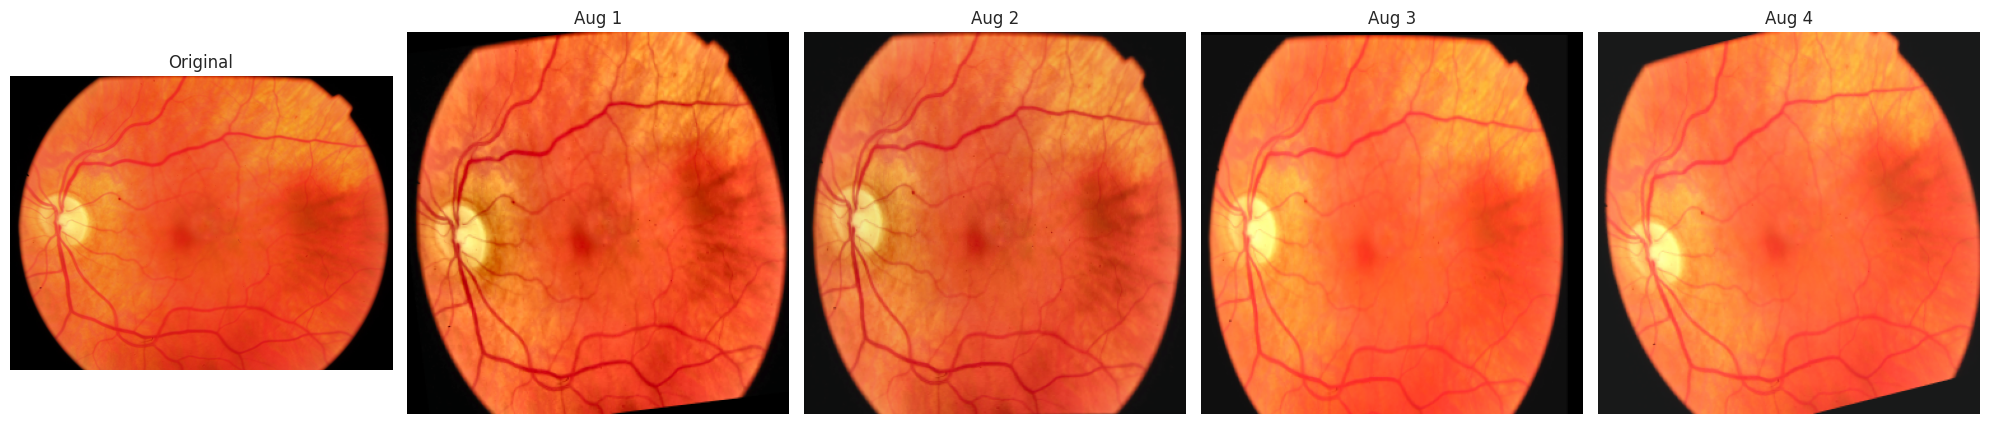

In [ ]:
# ============================================================
# VISUALIZAÇÃO DO PRÉ-PROCESSAMENTO
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

# selecionar uma imagem aleatória
sample_path = df.iloc[0]["image_path"]

image = cv2.imread(sample_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# aplicar augmentation algumas vezes
augmented_images = []

for _ in range(4):

    aug = train_transforms(image=image)

    img = aug["image"]

    img = img.permute(1,2,0).cpu().numpy()

    # desfazer normalização para visualização
    img = img * IMAGENET_STD + IMAGENET_MEAN

    img = np.clip(img, 0, 1)

    augmented_images.append(img)

# ============================================================
# EXIBIR
# ============================================================

fig, axes = plt.subplots(1, 5, figsize=(20,5))

axes[0].imshow(image)

axes[0].set_title("Original")

axes[0].axis("off")

for i in range(4):

    axes[i+1].imshow(augmented_images[i])

    axes[i+1].set_title(f"Aug {i+1}")

    axes[i+1].axis("off")

plt.tight_layout()
plt.show()

5. Divisão dos Dados em Treino, Validação e Teste
Objetivos

Nesta etapa o dataset é dividido em três subconjuntos independentes: treinamento, validação e teste. O conjunto de treinamento será utilizado para ajustar os pesos da rede neural, o conjunto de validação será empregado para monitorar o desempenho do modelo durante o treinamento e auxiliar na escolha dos melhores hiperparâmetros, enquanto o conjunto de teste será reservado para a avaliação final do sistema. Como o dataset possui pacientes com até duas imagens (olho esquerdo e direito), é fundamental evitar que imagens do mesmo paciente apareçam em conjuntos diferentes. Para isso, a divisão é realizada utilizando o identificador do paciente (patient_id) através do método GroupShuffleSplit, garantindo que cada paciente esteja presente em apenas um dos conjuntos e eliminando o risco de vazamento de informação (data leakage) entre treino, validação e teste.

DIVISÃO DOS DADOS

Total de imagens: 6469
Pacientes únicos: 4104


VERIFICAÇÃO DE LEAKAGE

Treino ∩ Validação: 0
Treino ∩ Teste: 0
Validação ∩ Teste: 0


RESUMO DOS SPLITS

TREINO
----------------------------------------
Imagens: 4527
Pacientes: 2872
Normais: 4337
Hipertensivas: 190
Taxa positiva: 4.20%

VALIDAÇÃO
----------------------------------------
Imagens: 956
Pacientes: 616
Normais: 901
Hipertensivas: 55
Taxa positiva: 5.75%

TESTE
----------------------------------------
Imagens: 986
Pacientes: 616
Normais: 947
Hipertensivas: 39
Taxa positiva: 3.96%


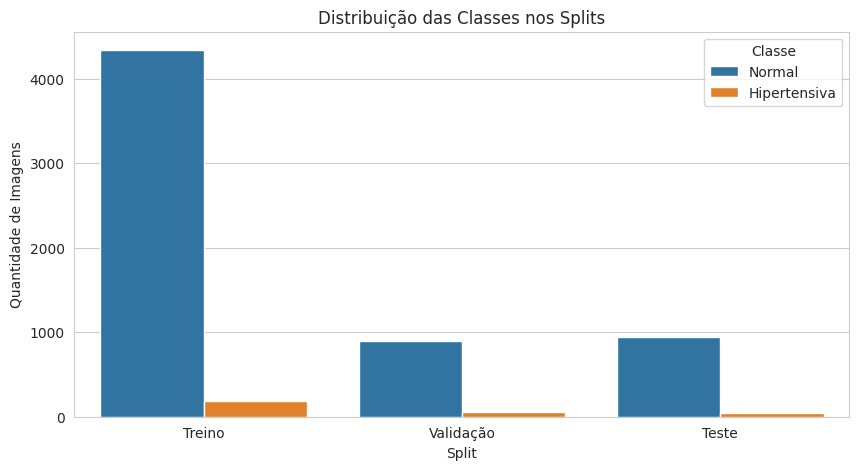



SPLITS SALVOS

Arquivos gerados:
train_split.csv
val_split.csv
test_split.csv


In [ ]:
# ============================================================
# ETAPA 5 — SPLIT TREINO / VALIDAÇÃO / TESTE
# ============================================================

from sklearn.model_selection import GroupShuffleSplit

# ============================================================
# CONFIGURAÇÕES
# ============================================================

VAL_SIZE = 0.15
TEST_SIZE = 0.15

print("=" * 70)
print("DIVISÃO DOS DADOS")
print("=" * 70)

print(f"\nTotal de imagens: {len(df)}")
print(f"Pacientes únicos: {df['patient_id'].nunique()}")

# ============================================================
# PRIMEIRA DIVISÃO
# TREINO (70%) x TEMPORÁRIO (30%)
# ============================================================

gss1 = GroupShuffleSplit(
    n_splits=1,
    test_size=VAL_SIZE + TEST_SIZE,
    random_state=SEED
)

train_idx, temp_idx = next(
    gss1.split(
        df,
        groups=df["patient_id"]
    )
)

train_df = df.iloc[train_idx].reset_index(drop=True)

temp_df = df.iloc[temp_idx].reset_index(drop=True)

# ============================================================
# SEGUNDA DIVISÃO
# VALIDAÇÃO (15%) x TESTE (15%)
# ============================================================

gss2 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.5,
    random_state=SEED
)

val_idx, test_idx = next(
    gss2.split(
        temp_df,
        groups=temp_df["patient_id"]
    )
)

val_df = temp_df.iloc[val_idx].reset_index(drop=True)

test_df = temp_df.iloc[test_idx].reset_index(drop=True)

# ============================================================
# VERIFICAÇÃO DE LEAKAGE
# ============================================================

train_patients = set(train_df["patient_id"])

val_patients = set(val_df["patient_id"])

test_patients = set(test_df["patient_id"])

print("\n")
print("=" * 70)
print("VERIFICAÇÃO DE LEAKAGE")
print("=" * 70)

print(
    "\nTreino ∩ Validação:",
    len(train_patients.intersection(val_patients))
)

print(
    "Treino ∩ Teste:",
    len(train_patients.intersection(test_patients))
)

print(
    "Validação ∩ Teste:",
    len(val_patients.intersection(test_patients))
)

# ============================================================
# RESUMO DOS CONJUNTOS
# ============================================================

print("\n")
print("=" * 70)
print("RESUMO DOS SPLITS")
print("=" * 70)

for nome, dataset in [
    ("TREINO", train_df),
    ("VALIDAÇÃO", val_df),
    ("TESTE", test_df)
]:

    total = len(dataset)

    positivos = (dataset["label"] == 1).sum()

    negativos = (dataset["label"] == 0).sum()

    pacientes = dataset["patient_id"].nunique()

    print(f"\n{nome}")

    print("-" * 40)

    print(f"Imagens: {total}")

    print(f"Pacientes: {pacientes}")

    print(f"Normais: {negativos}")

    print(f"Hipertensivas: {positivos}")

    print(
        f"Taxa positiva: "
        f"{100 * positivos / total:.2f}%"
    )

# ============================================================
# DISTRIBUIÇÃO DAS CLASSES
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

split_stats = []

for nome, dataset in [
    ("Treino", train_df),
    ("Validação", val_df),
    ("Teste", test_df)
]:

    split_stats.append({
        "Split": nome,
        "Classe": "Normal",
        "Quantidade": (dataset["label"] == 0).sum()
    })

    split_stats.append({
        "Split": nome,
        "Classe": "Hipertensiva",
        "Quantidade": (dataset["label"] == 1).sum()
    })

plot_df = pd.DataFrame(split_stats)

plt.figure(figsize=(10,5))

sns.barplot(
    data=plot_df,
    x="Split",
    y="Quantidade",
    hue="Classe"
)

plt.title("Distribuição das Classes nos Splits")

plt.ylabel("Quantidade de Imagens")

plt.show()

# ============================================================
# SALVAR SPLITS
# ============================================================

train_df.to_csv(
    OUT_DIR / "train_split.csv",
    index=False
)

val_df.to_csv(
    OUT_DIR / "val_split.csv",
    index=False
)

test_df.to_csv(
    OUT_DIR / "test_split.csv",
    index=False
)

print("\n")
print("=" * 70)
print("SPLITS SALVOS")
print("=" * 70)

print("\nArquivos gerados:")

print("train_split.csv")

print("val_split.csv")

print("test_split.csv")

6. Criação do Dataset PyTorch e dos DataLoaders
Objetivos

Nesta etapa é criada a estrutura responsável por fornecer os dados para a rede neural durante o treinamento, validação e teste. Para isso, é implementada uma classe personalizada baseada em torch.utils.data.Dataset, que recebe os dataframes gerados na etapa anterior e realiza automaticamente a leitura das imagens, aplicação das transformações de pré-processamento e retorno dos tensores utilizados pela EfficientNet-B3. Em seguida, são criados os DataLoaders, responsáveis por organizar os dados em mini-batches, embaralhar as amostras durante o treinamento e otimizar o carregamento das imagens. Como o dataset apresenta forte desbalanceamento entre as classes, também é utilizado um WeightedRandomSampler para aumentar a frequência de imagens positivas nos batches de treinamento, permitindo que o modelo aprenda melhor os padrões associados à retinopatia hipertensiva.

In [ ]:
# ============================================================
# ETAPA 6 — DATASET PYTORCH
# ============================================================

import cv2
import numpy as np
import torch
from torch.utils.data import Dataset

# ============================================================
# REMOVE BORDAS PRETAS
# ============================================================

def crop_black_borders(image, threshold=10):

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_RGB2GRAY
    )

    mask = gray > threshold

    if np.sum(mask) == 0:
        return image

    coords = np.argwhere(mask)

    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1

    cropped = image[
        y0:y1,
        x0:x1
    ]

    return cropped

# ============================================================
# DATASET
# ============================================================

class RetinaDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transforms=None
    ):

        self.df = dataframe.reset_index(drop=True)

        self.transforms = transforms

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image_path = row["image_path"]

        label = row["label"]

        # ----------------------------------------------------
        # Ler imagem
        # ----------------------------------------------------

        image = cv2.imread(image_path)

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        # ----------------------------------------------------
        # Crop da retina
        # ----------------------------------------------------

        image = crop_black_borders(image)

        # ----------------------------------------------------
        # Transformações
        # ----------------------------------------------------

        if self.transforms:

            image = self.transforms(
                image=image
            )["image"]

        label = torch.tensor(
            label,
            dtype=torch.float32
        )

        return image, label

In [ ]:
# ============================================================
# DATASETS
# ============================================================

train_dataset = RetinaDataset(
    train_df,
    transforms=train_transforms
)

val_dataset = RetinaDataset(
    val_df,
    transforms=valid_transforms
)

test_dataset = RetinaDataset(
    test_df,
    transforms=valid_transforms
)

print("=" * 70)
print("DATASETS CRIADOS")
print("=" * 70)

print(f"\nTreino: {len(train_dataset)}")

print(f"Validação: {len(val_dataset)}")

print(f"Teste: {len(test_dataset)}")

DATASETS CRIADOS

Treino: 4527
Validação: 956
Teste: 986


In [ ]:
# ============================================================
# WEIGHTED RANDOM SAMPLER
# ============================================================

from torch.utils.data import WeightedRandomSampler

class_counts = train_df["label"].value_counts()

print(class_counts)

n_negative = class_counts[0]

n_positive = class_counts[1]

weight_negative = 1.0 / n_negative

weight_positive = 1.0 / n_positive

sample_weights = train_df["label"].map({

    0: weight_negative,

    1: weight_positive

}).values

sampler = WeightedRandomSampler(

    weights=sample_weights,

    num_samples=len(sample_weights),

    replacement=True
)

print("\nSampler criado.")

label
0    4337
1     190
Name: count, dtype: int64

Sampler criado.


In [ ]:
# ============================================================
# DATALOADERS
# ============================================================

from torch.utils.data import DataLoader

train_loader = DataLoader(

    train_dataset,

    batch_size=32,

    sampler=sampler,

    num_workers=2,

    pin_memory=True
)

val_loader = DataLoader(

    val_dataset,

    batch_size=32,

    shuffle=False,

    num_workers=2,

    pin_memory=True
)

test_loader = DataLoader(

    test_dataset,

    batch_size=32,

    shuffle=False,

    num_workers=2,

    pin_memory=True
)

print("=" * 70)
print("DATALOADERS CRIADOS")
print("=" * 70)

print(f"\nTrain batches: {len(train_loader)}")

print(f"Validation batches: {len(val_loader)}")

print(f"Test batches: {len(test_loader)}")

DATALOADERS CRIADOS

Train batches: 142
Validation batches: 30
Test batches: 31


In [ ]:
# ============================================================
# TESTE DO DATALOADER
# ============================================================

images, labels = next(iter(train_loader))

print("=" * 70)
print("TESTE DO DATALOADER")
print("=" * 70)

print("\nShape das imagens:")

print(images.shape)

print("\nShape dos labels:")

print(labels.shape)

print("\nPrimeiros labels:")

print(labels[:10])

TESTE DO DATALOADER

Shape das imagens:
torch.Size([32, 3, 300, 300])

Shape dos labels:
torch.Size([32])

Primeiros labels:
tensor([0., 1., 0., 1., 1., 0., 1., 1., 0., 0.])


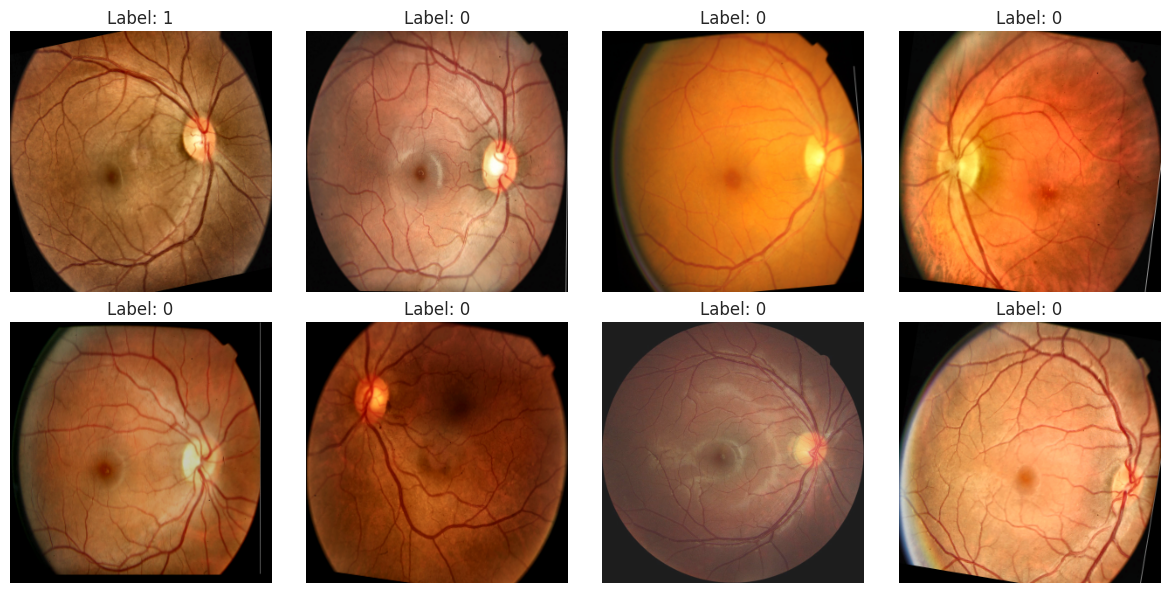

In [ ]:
# ============================================================
# VISUALIZAÇÃO DE UM BATCH
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(
    2,
    4,
    figsize=(12,6)
)

axes = axes.flatten()

for i in range(8):

    img = images[i].cpu().permute(1,2,0).numpy()

    img = img * IMAGENET_STD + IMAGENET_MEAN

    img = np.clip(img, 0, 1)

    axes[i].imshow(img)

    axes[i].set_title(
        f"Label: {int(labels[i].item())}"
    )

    axes[i].axis("off")

plt.tight_layout()

plt.show()

7. Construção do Modelo EfficientNet-B3
Objetivos

Nesta etapa é construída a rede neural que será utilizada para detectar a presença de retinopatia hipertensiva nas imagens de fundo de olho. Será utilizada a arquitetura EfficientNet-B3 com pesos pré-treinados no ImageNet, aproveitando o conhecimento previamente adquirido pelo modelo sobre padrões visuais gerais. Como o problema é uma classificação binária (normal ou hipertensiva), a camada final original será substituída por uma nova camada totalmente conectada com apenas uma saída. O treinamento será realizado em duas fases: inicialmente apenas a cabeça classificadora será treinada, mantendo o restante da rede congelado; posteriormente toda a rede será descongelada para realizar o fine tuning completo, permitindo que os pesos se adaptem às características específicas das imagens oftalmológicas.

In [ ]:
# ============================================================
# ETAPA 7 — MODELO EFFICIENTNET-B3
# ============================================================

import timm
import torch
import torch.nn as nn

# ============================================================
# CRIAR MODELO
# ============================================================

model = timm.create_model(

    "efficientnet_b3",

    pretrained=True,

    num_classes=1
)

model = model.to(DEVICE)

print("=" * 70)
print("MODELO CRIADO")
print("=" * 70)

print(model)

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

MODELO CRIADO
EfficientNet(
  (conv_stem): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
        (bn1): BatchNormAct2d(
          40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(40, 24, kernel_size=(1, 1), stride=(1, 1), bias=Fal

In [ ]:
# ============================================================
# CONTAGEM DE PARÂMETROS
# ============================================================

total_params = sum(

    p.numel()

    for p in model.parameters()
)

trainable_params = sum(

    p.numel()

    for p in model.parameters()

    if p.requires_grad
)

print("=" * 70)
print("PARÂMETROS")
print("=" * 70)

print(f"\nTotal: {total_params:,}")

print(f"Treináveis: {trainable_params:,}")

PARÂMETROS

Total: 10,697,769
Treináveis: 10,697,769


Congelar Backbone


In [ ]:
# ============================================================
# FASE 1 — CONGELAR BACKBONE
# ============================================================

for param in model.parameters():

    param.requires_grad = False

# liberar apenas classificador final

for param in model.classifier.parameters():

    param.requires_grad = True

print("=" * 70)
print("FASE 1")
print("=" * 70)

trainable_params = sum(

    p.numel()

    for p in model.parameters()

    if p.requires_grad
)

print(f"\nParâmetros treináveis: {trainable_params:,}")

FASE 1

Parâmetros treináveis: 1,537


In [ ]:
# ============================================================
# OTIMIZADOR FASE 1
# ============================================================

optimizer_head = torch.optim.AdamW(

    model.classifier.parameters(),

    lr=1e-3,

    weight_decay=1e-4
)

print("Optimizer da fase 1 criado.")

Optimizer da fase 1 criado.


In [ ]:
# ============================================================
# FOCAL LOSS
# ============================================================

class FocalLoss(nn.Module):

    def __init__(
        self,
        alpha=0.75,
        gamma=2
    ):

        super().__init__()

        self.alpha = alpha

        self.gamma = gamma

    def forward(
        self,
        logits,
        targets
    ):

        targets = targets.float()

        bce = nn.functional.binary_cross_entropy_with_logits(

            logits.squeeze(),

            targets,

            reduction="none"
        )

        pt = torch.exp(-bce)

        focal = (

            self.alpha

            * (1 - pt) ** self.gamma

            * bce
        )

        return focal.mean()

criterion = FocalLoss(
    alpha=0.50,
    gamma=2.0
)

print("Focal Loss criada.")

Focal Loss criada.


In [ ]:
# ============================================================
# LEARNING RATE SCHEDULER
# ============================================================

scheduler_head = torch.optim.lr_scheduler.ReduceLROnPlateau(

    optimizer_head,

    mode="max",

    factor=0.5,

    patience=2
)

print("Scheduler criado.")

Scheduler criado.


In [ ]:
# ============================================================
# TESTE DE FORWARD
# ============================================================

images, labels = next(iter(train_loader))

images = images.to(DEVICE)

with torch.no_grad():

    outputs = model(images)

print("=" * 70)
print("TESTE DE FORWARD")
print("=" * 70)

print("\nInput:")

print(images.shape)

print("\nOutput:")

print(outputs.shape)

TESTE DE FORWARD

Input:
torch.Size([32, 3, 300, 300])

Output:
torch.Size([32, 1])


Descongelar tudo fase 2

In [ ]:
# ============================================================
# FASE 2 — DESCONGELAR MODELO
# ============================================================

def unfreeze_model(model):

    for param in model.parameters():

        param.requires_grad = True

    optimizer_full = torch.optim.AdamW(

        model.parameters(),

        lr=1e-4,

        weight_decay=1e-4
    )

    scheduler_full = torch.optim.lr_scheduler.ReduceLROnPlateau(

        optimizer_full,

        mode="max",

        factor=0.5,

        patience=2
    )

    return optimizer_full, scheduler_full

8. Treinamento do Modelo
Objetivos

Nesta etapa é implementado o processo de treinamento da EfficientNet-B3 para classificação binária de retinopatia hipertensiva. Durante cada época, o modelo recebe lotes de imagens do conjunto de treinamento, realiza a propagação direta (forward pass), calcula a função de perda, ajusta seus pesos através do algoritmo de retropropagação (backpropagation) e atualiza os parâmetros utilizando o otimizador AdamW. Ao final de cada época, o modelo é avaliado no conjunto de validação por meio de métricas como Recall, Precision, F1-Score, ROC-AUC e PR-AUC. Também é utilizado Early Stopping para interromper automaticamente o treinamento caso não haja melhora após um determinado número de épocas, além de salvar automaticamente os pesos do melhor modelo encontrado durante o processo.

In [ ]:
# ============================================================
# ETAPA 8 — TREINAMENTO
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

import numpy as np
from tqdm.auto import tqdm
import torch

In [ ]:
# ============================================================
# TREINO DE UMA ÉPOCA
# ============================================================

def train_one_epoch(

    model,
    loader,
    optimizer,
    criterion,
    device

):

    model.train()

    running_loss = 0

    all_preds = []

    all_targets = []

    pbar = tqdm(loader)

    for images, labels in pbar:

        images = images.to(device)

        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images).squeeze(1)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        probs = torch.sigmoid(outputs)

        preds = (probs > 0.5).float()

        all_preds.extend(
            preds.detach().cpu().numpy()
        )

        all_targets.extend(
            labels.detach().cpu().numpy()
        )

        pbar.set_description(
            f"Loss: {loss.item():.4f}"
        )

    epoch_loss = running_loss / len(loader)

    accuracy = accuracy_score(
        all_targets,
        all_preds
    )

    return epoch_loss, accuracy

In [ ]:
# ============================================================
# VALIDAÇÃO
# ============================================================

@torch.no_grad()

def validate(

    model,
    loader,
    criterion,
    device

):

    model.eval()

    running_loss = 0

    probs_list = []

    preds_list = []

    targets_list = []

    for images, labels in loader:

        images = images.to(device)

        labels = labels.to(device)

        outputs = model(images).squeeze(1)

        loss = criterion(
            outputs,
            labels
        )

        running_loss += loss.item()

        probs = torch.sigmoid(outputs)

        preds = (probs > 0.5).float()

        probs_list.extend(
            probs.cpu().numpy()
        )

        preds_list.extend(
            preds.cpu().numpy()
        )

        targets_list.extend(
            labels.cpu().numpy()
        )

    loss = running_loss / len(loader)

    accuracy = accuracy_score(
        targets_list,
        preds_list
    )

    precision = precision_score(
        targets_list,
        preds_list,
        zero_division=0
    )

    recall = recall_score(
        targets_list,
        preds_list,
        zero_division=0
    )

    f1 = f1_score(
        targets_list,
        preds_list,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        targets_list,
        probs_list
    )

    pr_auc = average_precision_score(
        targets_list,
        probs_list
    )

    return {

        "loss": loss,

        "accuracy": accuracy,

        "precision": precision,

        "recall": recall,

        "f1": f1,

        "roc_auc": roc_auc,

        "pr_auc": pr_auc
    }

In [ ]:
# ============================================================
# EARLY STOPPING
# ============================================================

class EarlyStopping:

    def __init__(

        self,

        patience=5

    ):

        self.patience = patience

        self.best_score = -np.inf

        self.counter = 0

    def step(self, score):

        if score > self.best_score:

            self.best_score = score

            self.counter = 0

            return False

        self.counter += 1

        return self.counter >= self.patience

In [ ]:
# ============================================================
# TREINAMENTO DA HEAD
# ============================================================

HEAD_EPOCHS = 5

early_stopping = EarlyStopping(
    patience=5
)

best_pr_auc = 0

history = []

for epoch in range(HEAD_EPOCHS):

    print("\n")
    print("=" * 70)

    print(
        f"HEAD EPOCH "
        f"{epoch+1}/{HEAD_EPOCHS}"
    )

    print("=" * 70)

    train_loss, train_acc = train_one_epoch(

        model,

        train_loader,

        optimizer_head,

        criterion,

        DEVICE
    )

    metrics = validate(

        model,

        val_loader,

        criterion,

        DEVICE
    )

    scheduler_head.step(
        metrics["pr_auc"]
    )

    print(
        f"\nTrain Loss: {train_loss:.4f}"
    )

    print(
        f"Val Loss: {metrics['loss']:.4f}"
    )

    print(
        f"Recall: {metrics['recall']:.4f}"
    )

    print(
        f"F1: {metrics['f1']:.4f}"
    )

    print(
        f"ROC-AUC: {metrics['roc_auc']:.4f}"
    )

    print(
        f"PR-AUC: {metrics['pr_auc']:.4f}"
    )

    history.append({

        "phase": "head",

        "epoch": epoch,

        **metrics
    })

    if metrics["pr_auc"] > best_pr_auc:

        best_pr_auc = metrics["pr_auc"]

        torch.save(

            model.state_dict(),

            OUT_DIR / "best_head.pth"
        )

        print("\nMelhor modelo salvo.")

    if early_stopping.step(

        metrics["pr_auc"]

    ):

        print(
            "\nEarly stopping."
        )

        break



HEAD EPOCH 1/5


  0%|          | 0/142 [00:00<?, ?it/s]


Train Loss: 0.7041
Val Loss: 0.6123
Recall: 0.4727
F1: 0.1116
ROC-AUC: 0.5354
PR-AUC: 0.0743

Melhor modelo salvo.


HEAD EPOCH 2/5


  0%|          | 0/142 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a6f50df56c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a6f50df56c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

...


Train Loss: 0.4382
Val Loss: 0.4337
Recall: 0.4727
F1: 0.1333
ROC-AUC: 0.5906
PR-AUC: 0.0831

Melhor modelo salvo.


HEAD EPOCH 4/5


  0%|          | 0/142 [00:00<?, ?it/s]


Train Loss: 0.4059
Val Loss: 0.4861
Recall: 0.4909
F1: 0.1236
ROC-AUC: 0.6041
PR-AUC: 0.0857

Melhor modelo salvo.


HEAD EPOCH 5/5


  0%|          | 0/142 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a6f50df56c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a6f50df56c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

In [ ]:
# ============================================================
# FASE 2
# ============================================================

optimizer_full, scheduler_full = (

    unfreeze_model(model)
)

FULL_EPOCHS = 15

early_stopping = EarlyStopping(
    patience=5
)

for epoch in range(FULL_EPOCHS):

    print("\n")
    print("=" * 70)

    print(
        f"FULL EPOCH "
        f"{epoch+1}/{FULL_EPOCHS}"
    )

    print("=" * 70)

    train_loss, train_acc = train_one_epoch(

        model,

        train_loader,

        optimizer_full,

        criterion,

        DEVICE
    )

    metrics = validate(

        model,

        val_loader,

        criterion,

        DEVICE
    )

    scheduler_full.step(
        metrics["pr_auc"]
    )

    print(
        f"\nTrain Loss: {train_loss:.4f}"
    )

    print(
        f"Val Loss: {metrics['loss']:.4f}"
    )

    print(
        f"Recall: {metrics['recall']:.4f}"
    )

    print(
        f"F1: {metrics['f1']:.4f}"
    )

    print(
        f"ROC-AUC: {metrics['roc_auc']:.4f}"
    )

    print(
        f"PR-AUC: {metrics['pr_auc']:.4f}"
    )

    history.append({

        "phase": "full",

        "epoch": epoch,

        **metrics
    })

    if metrics["pr_auc"] > best_pr_auc:

        best_pr_auc = metrics["pr_auc"]

        torch.save(

            model.state_dict(),

            OUT_DIR / "best_model.pth"
        )

        print(
            "\nMelhor modelo salvo."
        )

    if early_stopping.step(

        metrics["pr_auc"]

    ):

        print(
            "\nEarly stopping."
        )

        break

In [ ]:
# ============================================================
# HISTÓRICO
# ============================================================

history_df = pd.DataFrame(history)

history_df.to_csv(

    OUT_DIR / "training_history.csv",

    index=False
)

display(history_df.tail())

In [ ]:
# ============================================================
# CURVAS DE TREINAMENTO
# ============================================================

plt.figure(figsize=(12,5))

plt.plot(
    history_df["loss"],
    label="Validation Loss"
)

plt.legend()

plt.title(
    "Loss ao longo do treinamento"
)

plt.show()

plt.figure(figsize=(12,5))

plt.plot(
    history_df["pr_auc"],
    label="PR-AUC"
)

plt.plot(
    history_df["roc_auc"],
    label="ROC-AUC"
)

plt.legend()

plt.title(
    "Métricas de Validação"
)

plt.show()

9. Avaliação Final no Conjunto de Teste
Objetivos

Após o treinamento e seleção do melhor modelo durante a validação, é necessário realizar uma avaliação final utilizando o conjunto de teste, que permaneceu completamente isolado durante o desenvolvimento da rede. Essa etapa tem como objetivo estimar o desempenho real da EfficientNet-B3 em dados nunca vistos anteriormente, fornecendo uma medida mais confiável da capacidade de generalização do modelo. Para isso, são calculadas métricas amplamente utilizadas em problemas de classificação médica, incluindo Accuracy, Precision, Recall, F1-Score, ROC-AUC e PR-AUC. Além disso, são armazenadas as probabilidades previstas para cada imagem, permitindo análises posteriores como ajuste de threshold, construção da matriz de confusão, curvas ROC e Precision-Recall.

In [ ]:
# ============================================================
# ETAPA 9 — AVALIAÇÃO FINAL
# ============================================================

import torch

# carregar melhor modelo salvo

model.load_state_dict(

    torch.load(

        OUT_DIR / "best_model.pth",

        map_location=DEVICE
    )
)

model.eval()

print("=" * 70)
print("MODELO CARREGADO")
print("=" * 70)

print("\nPesos carregados com sucesso.")

In [ ]:
# ============================================================
# AVALIAÇÃO NO TESTE
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

@torch.no_grad()
def evaluate_test_set(

    model,
    loader,
    device,
    threshold=0.5

):

    model.eval()

    all_probs = []
    all_preds = []
    all_labels = []

    for images, labels in loader:

        images = images.to(device)

        outputs = model(images)

        probs = torch.sigmoid(
            outputs.squeeze()
        )

        preds = (
            probs >= threshold
        ).float()

        all_probs.extend(
            probs.cpu().numpy()
        )

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

    metrics = {

        "accuracy": accuracy_score(
            all_labels,
            all_preds
        ),

        "precision": precision_score(
            all_labels,
            all_preds,
            zero_division=0
        ),

        "recall": recall_score(
            all_labels,
            all_preds,
            zero_division=0
        ),

        "f1": f1_score(
            all_labels,
            all_preds,
            zero_division=0
        ),

        "roc_auc": roc_auc_score(
            all_labels,
            all_probs
        ),

        "pr_auc": average_precision_score(
            all_labels,
            all_probs
        )
    }

    return (

        metrics,

        np.array(all_labels),

        np.array(all_preds),

        np.array(all_probs)
    )

In [ ]:
# ============================================================
# EXECUTAR TESTE
# ============================================================

test_metrics, y_true, y_pred, y_prob = (

    evaluate_test_set(

        model,

        test_loader,

        DEVICE,

        threshold=BEST_THRESHOLD
    )
)

In [ ]:
# ============================================================
# RESULTADOS
# ============================================================

print("=" * 70)
print("RESULTADOS NO CONJUNTO DE TESTE")
print("=" * 70)

for metric, value in test_metrics.items():

    print(

        f"{metric.upper():<12}: "

        f"{value:.4f}"
    )

In [ ]:
# ============================================================
# SALVAR MÉTRICAS
# ============================================================

results_df = pd.DataFrame(

    [test_metrics]
)

results_df.to_csv(

    OUT_DIR / "test_metrics.csv",

    index=False
)

print("\nMétricas salvas.")

In [ ]:
# ============================================================
# DISTRIBUIÇÃO DAS PROBABILIDADES
# ============================================================

plt.figure(figsize=(8,5))

plt.hist(

    y_prob,

    bins=30
)

plt.title(
    "Distribuição das Probabilidades"
)

plt.xlabel(
    "Probabilidade de Retinopatia Hipertensiva"
)

plt.ylabel(
    "Quantidade"
)

plt.show()

In [ ]:
# ============================================================
# SALVAR PREDIÇÕES
# ============================================================

predictions_df = pd.DataFrame({

    "real_label": y_true,

    "predicted_label": y_pred,

    "probability_hr": y_prob

})

predictions_df.to_csv(

    OUT_DIR / "test_predictions.csv",

    index=False
)

display(
    predictions_df.head()
)

In [ ]:
# ============================================================
# ETAPA 9.5 — OTIMIZAÇÃO DE THRESHOLD
# ============================================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

@torch.no_grad()
def collect_validation_probs(

    model,
    loader,
    device

):

    model.eval()

    probs = []
    labels = []

    for images, targets in loader:

        images = images.to(device)

        outputs = model(images)

        pred_probs = torch.sigmoid(
            outputs.squeeze()
        )

        probs.extend(
            pred_probs.cpu().numpy()
        )

        labels.extend(
            targets.numpy()
        )

    return (
        np.array(labels),
        np.array(probs)
    )

val_labels, val_probs = collect_validation_probs(

    model,
    val_loader,
    DEVICE
)

results = []

for thr in np.arange(0.05, 0.96, 0.05):

    preds = (
        val_probs >= thr
    ).astype(int)

    precision = precision_score(
        val_labels,
        preds,
        zero_division=0
    )

    recall = recall_score(
        val_labels,
        preds,
        zero_division=0
    )

    f1 = f1_score(
        val_labels,
        preds,
        zero_division=0
    )

    results.append([

        thr,
        precision,
        recall,
        f1

    ])

threshold_df = pd.DataFrame(

    results,

    columns=[
        "threshold",
        "precision",
        "recall",
        "f1"
    ]
)

display(
    threshold_df.sort_values(
        "f1",
        ascending=False
    ).head(10)
)

best_row = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

BEST_THRESHOLD = float(
    best_row["threshold"]
)

print(
    f"\nMelhor threshold: "
    f"{BEST_THRESHOLD:.2f}"
)

10. Matriz de Confusão e Análise dos Erros
Objetivos

Após avaliar o desempenho geral da EfficientNet-B3 através das métricas de teste, é importante analisar detalhadamente os tipos de erros cometidos pelo modelo. Para isso, utiliza-se a matriz de confusão, uma ferramenta amplamente empregada em aplicações médicas para visualizar a quantidade de classificações corretas e incorretas realizadas pela rede neural. A partir dela é possível identificar quantos casos de retinopatia hipertensiva foram corretamente detectados (True Positives), quantos pacientes saudáveis foram corretamente classificados (True Negatives), além dos falsos positivos e falsos negativos. Essa análise permite compreender melhor o comportamento do sistema e avaliar se ele é adequado para uso como ferramenta de triagem, onde normalmente é desejável maximizar a detecção dos casos positivos.

In [ ]:
# ============================================================
# ETAPA 10 — MATRIZ DE CONFUSÃO
# ============================================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_true,
    y_pred
)

print("=" * 70)
print("MATRIZ DE CONFUSÃO")
print("=" * 70)

print(cm)

In [ ]:
# ============================================================
# HEATMAP
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=[
        "Normal",
        "Hipertensiva"
    ],

    yticklabels=[
        "Normal",
        "Hipertensiva"
    ]
)

plt.xlabel("Predição")

plt.ylabel("Classe Real")

plt.title(
    "Matriz de Confusão"
)

plt.show()

In [ ]:
# ============================================================
# COMPONENTES DA MATRIZ
# ============================================================

tn, fp, fn, tp = cm.ravel()

print("=" * 70)
print("COMPONENTES")
print("=" * 70)

print(f"\nTrue Negative  (TN): {tn}")

print(f"False Positive (FP): {fp}")

print(f"False Negative (FN): {fn}")

print(f"True Positive  (TP): {tp}")

In [ ]:
# ============================================================
# MÉTRICAS CLÍNICAS
# ============================================================

sensitivity = tp / (tp + fn)

specificity = tn / (tn + fp)

npv = tn / (tn + fn)

ppv = tp / (tp + fp)

print("=" * 70)
print("MÉTRICAS CLÍNICAS")
print("=" * 70)

print(
    f"\nSensibilidade (Recall): "
    f"{sensitivity:.4f}"
)

print(
    f"Especificidade: "
    f"{specificity:.4f}"
)

print(
    f"Valor Preditivo Positivo (PPV): "
    f"{ppv:.4f}"
)

print(
    f"Valor Preditivo Negativo (NPV): "
    f"{npv:.4f}"
)

In [ ]:
# ============================================================
# MATRIZ NORMALIZADA
# ============================================================

cm_percent = (

    cm.astype(float)

    / cm.sum(axis=1)[:, np.newaxis]

)

plt.figure(figsize=(7,6))

sns.heatmap(

    cm_percent,

    annot=True,

    fmt=".2%",

    cmap="Greens",

    xticklabels=[
        "Normal",
        "Hipertensiva"
    ],

    yticklabels=[
        "Normal",
        "Hipertensiva"
    ]
)

plt.xlabel("Predição")

plt.ylabel("Classe Real")

plt.title(
    "Matriz de Confusão (%)"
)

plt.show()

In [ ]:
# ============================================================
# AMOSTRAS ERRADAS
# ============================================================

test_results_df = test_df.copy()

test_results_df["pred"] = y_pred

test_results_df["prob"] = y_prob

errors_df = test_results_df[
    test_results_df["label"] != test_results_df["pred"]
]

print("=" * 70)
print("ERROS ENCONTRADOS")
print("=" * 70)

print(
    f"\nQuantidade: "
    f"{len(errors_df)}"
)

display(
    errors_df.head()
)

In [ ]:
# ============================================================
# FALSOS NEGATIVOS
# ============================================================

false_negatives = errors_df[
    (errors_df["label"] == 1)
    &
    (errors_df["pred"] == 0)
]

print(
    f"Falsos Negativos: "
    f"{len(false_negatives)}"
)

In [ ]:
# ============================================================
# VISUALIZAR FALSOS NEGATIVOS
# ============================================================

from PIL import Image

n_show = min(6, len(false_negatives))

fig, axes = plt.subplots(
    1,
    n_show,
    figsize=(16,4)
)

if n_show == 1:
    axes = [axes]

for ax, (_, row) in zip(
    axes,
    false_negatives.head(n_show).iterrows()
):

    img = Image.open(
        row["image_path"]
    )

    ax.imshow(img)

    ax.set_title(
        f"P={row['prob']:.2f}"
    )

    ax.axis("off")

plt.suptitle(
    "Falsos Negativos"
)

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# FALSOS POSITIVOS
# ============================================================

false_positives = errors_df[
    (errors_df["label"] == 0)
    &
    (errors_df["pred"] == 1)
]

print(
    f"Falsos Positivos: "
    f"{len(false_positives)}"
)

In [ ]:
# ============================================================
# MOSTRAR FALSOS POSITIVOS
# ============================================================

n_show = min(6, len(false_positives))

fig, axes = plt.subplots(
    1,
    n_show,
    figsize=(16,4)
)

if n_show == 1:
    axes = [axes]

for ax, (_, row) in zip(
    axes,
    false_positives.head(n_show).iterrows()
):

    img = Image.open(
        row["image_path"]
    )

    ax.imshow(img)

    ax.set_title(
        f"P={row['prob']:.2f}"
    )

    ax.axis("off")

plt.suptitle(
    "Falsos Positivos"
)

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# SALVAR ERROS
# ============================================================

errors_df.to_csv(

    OUT_DIR / "misclassified_images.csv",

    index=False
)

print(
    "Arquivo salvo:"
)

print(
    OUT_DIR / "misclassified_images.csv"
)

11. Interpretabilidade com Grad-CAM
Objetivos

Embora métricas como Accuracy, Recall e ROC-AUC indiquem o desempenho do modelo, elas não explicam quais regiões da imagem influenciaram a decisão da rede neural. Em aplicações médicas, essa interpretabilidade é extremamente importante para verificar se o modelo está aprendendo características clínicas relevantes ou apenas explorando padrões espúrios presentes no dataset. Para isso, utiliza-se a técnica Grad-CAM (Gradient-weighted Class Activation Mapping), que gera mapas de calor sobrepostos à imagem original destacando as regiões que mais contribuíram para a predição. No contexto da retinopatia hipertensiva, espera-se que o modelo concentre sua atenção em estruturas vasculares da retina, cruzamentos arteriovenosos, alterações de calibre vascular, exsudatos e outras lesões relacionadas à doença. Essa etapa permite validar visualmente o comportamento da rede e identificar possíveis problemas de aprendizado.

In [ ]:
!pip install -q grad-cam

In [ ]:
# ============================================================
# ETAPA 14 — GRAD-CAM
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

from PIL import Image

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [ ]:
# ============================================================
# CAMADA ALVO
# ============================================================

target_layers = [
    model.conv_head
]
# ============================================================
# FUNÇÃO GRAD-CAM
# ============================================================

cam = GradCAM(

    model=model,

    target_layers=target_layers
)

def generate_gradcam(

    image_path

):

    image = cv2.imread(image_path)

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    image_resized = cv2.resize(
        image,
        (300,300)
    )

    image_float = (
        image_resized.astype(np.float32)
        / 255.0
    )

    transformed = valid_transforms(
        image=image_resized
    )["image"]

    input_tensor = (
        transformed
        .unsqueeze(0)
        .to(DEVICE)
    )

    grayscale_cam = cam(
        input_tensor=input_tensor
    )[0]

    visualization = show_cam_on_image(

        image_float,

        grayscale_cam,

        use_rgb=True
    )

    return (

        image_resized,

        visualization
    )

    sample_path = test_df.iloc[0]["image_path"]

sample_label = test_df.iloc[0]["label"]

print(sample_path)

print("Label:", sample_label)

original, gradcam_img = generate_gradcam(
    sample_path
)

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)

plt.imshow(original)

plt.title("Imagem Original")

plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(gradcam_img)

plt.title("Grad-CAM")

plt.axis("off")

plt.show()

# ============================================================
# CASOS CORRETOS
# ============================================================

correct_df = test_results_df[
    test_results_df["label"]
    ==
    test_results_df["pred"]
]

samples = correct_df.sample(
    min(4, len(correct_df)),
    random_state=42
)

for _, row in samples.iterrows():

    original, gradcam_img = (

        generate_gradcam(
            row["image_path"]
        )
    )

    fig, ax = plt.subplots(
        1,
        2,
        figsize=(10,4)
    )

    ax[0].imshow(original)

    ax[0].set_title(
        f"Real={row['label']}"
    )

    ax[0].axis("off")

    ax[1].imshow(gradcam_img)

    ax[1].set_title(
        f"Prob={row['prob']:.2f}"
    )

    ax[1].axis("off")

    plt.show()



In [ ]:
# ============================================================
# FALSOS NEGATIVOS
# ============================================================

false_negatives = test_results_df[
    (test_results_df["label"] == 1)
    &
    (test_results_df["pred"] == 0)
]

print(
    f"Quantidade: "
    f"{len(false_negatives)}"
)

In [ ]:
for _, row in false_negatives.head(5).iterrows():

    original, gradcam_img = (

        generate_gradcam(
            row["image_path"]
        )
    )

    fig, ax = plt.subplots(
        1,
        2,
        figsize=(10,4)
    )

    ax[0].imshow(original)

    ax[0].set_title(
        "Falso Negativo"
    )

    ax[0].axis("off")

    ax[1].imshow(gradcam_img)

    ax[1].set_title(
        f"Prob={row['prob']:.2f}"
    )

    ax[1].axis("off")

    plt.show()

In [ ]:
# ============================================================
# SALVAR GRAD-CAMS
# ============================================================

SAVE_DIR = OUT_DIR / "gradcam_examples"

SAVE_DIR.mkdir(
    exist_ok=True,
    parents=True
)

for idx, row in enumerate(

    false_negatives.head(10).itertuples()

):

    _, gradcam_img = (

        generate_gradcam(
            row.image_path
        )
    )

    save_path = (

        SAVE_DIR
        /
        f"gradcam_{idx}.jpg"
    )

    Image.fromarray(

        gradcam_img

    ).save(save_path)

print(
    f"Arquivos salvos em:\n{SAVE_DIR}"
)